# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

What can be said about the outliers in the top left? 
    • They were low on PCA 1's spread, but high on PCA 2's
    • This combination is more unique within this data set (not seen in many other points)


Is the first PCA score high or low?
    • PCA1 has a highest value of .9159
    • From my googling, there is no set threshold to determine if a PCA is "high" or "low", but it seems like this accounts for a large majority of variation
    • Values seem more clustered around 0, but a decent proportion fall either low or high


Is the second PCA score high or low?
    • 2 variables seem to account for a lot of the variation in PCA2 with values of .603 and .689
    • These are lower values than PCA, but combined with PCA much of the variation is accounted for 
    • Values are more clustered around 0 than in PCA1, but there is still a wide spread of values. On visual inspection, it seems that more values fall lower than 0 compared to the higher values


What does that mean about their values in series_1, series_2, and series_3?
    • A wide spread with no obvious clusters implies that on a multivariate level there is a lot of variation amongst the samples


Thoughts on series_3?
    • Series 3 is a significant contributor to the variation - looking at PCA1 the variation is primarily explained by series3 data & much of PCA2 is also explained by this data


Why is it harder to say something about series_1 and series_2?
    • Series 3 dominates PCA1 compared to series 1 and 2
    • Series 1 and 2 have very similar values in PCA2, but PCA explains a significantly lower proportion of the variance than PCA1 does


How are series_1 and series_2 related? Look at how they were made
    • Both series 2 and 3 start with the series 1 data and then are multiplied by random numbers
    • I think that might make them linearly dependent


Advantages
    • Lower dimensional plot than trying to plot all 3 series at once
    • The spread can be used for a quick visual inspection of the relationships between the PCAs
    • Clustering of values can be useful


Disadvantages
    • Very much relies on an audience who understands statistics
    • Can't see all 3 series (maybe a bubble plot would be appropriate?)
    • Can't interpret in a concrete way - need other analyses to do so


In [1]:
# ! pip install matplotlib
# ! pip install pandas
# ! pip install numpy
# ! pip install scikit-learn

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

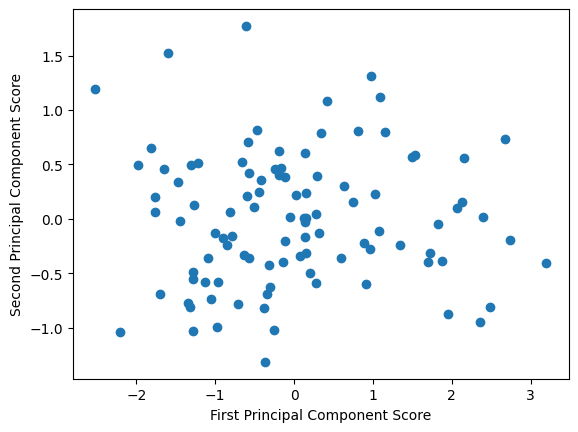

In [2]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

Text(0.5, 1.0, 'Distribution of Customers')

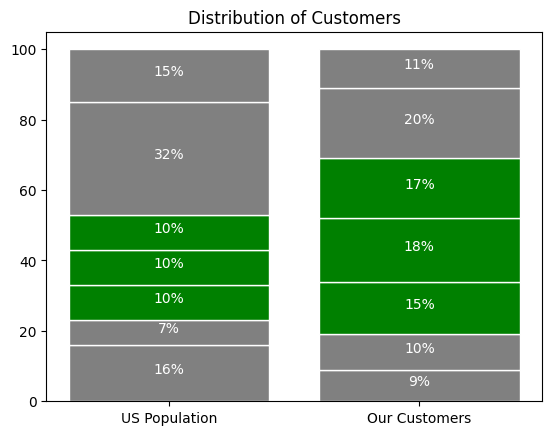

In [16]:
# figure 5.13

# start by making the 2 bar groups, segment names, highlighted groups by index position, and bar position/start
us_population = [16, 7, 10, 10, 10, 32, 15]
customers = [9, 10, 15, 18, 17, 20, 11]
segments = ["Segment 1","Segment 2","Segment 3", "Segment 4", "Segment 5", "Segment 6", "Segment 7"] 
hilighted_segments = [2,3,4]
bar1 = 0
bar2 = 1
bar1_start = 0
bar2_start = 0

# now set the sections to highlight
for c in range(len(us_population)):
    if c in hilighted_segments:
        color = "green"
        text_color = "white"
    else:
        color = "grey"
        text_color = "white"

    # now make the bars
    plt.bar(bar1, us_population[c], bottom=bar1_start, color=color, edgecolor="white")
    plt.text(bar1, bar1_start + us_population[c] / 2, f"{us_population[c]}%", ha="center", color=text_color)
    plt.bar(bar2, customers[c], bottom=bar2_start, color=color, edgecolor="white")
    plt.text(bar2, bar2_start + customers[c] / 2, f"{customers[c]}%", ha="center", color=text_color)
    bar1_start += us_population[c]
    bar2_start += customers[c]

# labels
plt.xticks([bar1, bar2], ["US Population", "Our Customers"])
plt.title("Distribution of Customers")